In [ ]:
# install the stuff I need in Colab (I usually run this in a separate cell there)
!pip -q install -U transformers accelerate datasets evaluate sentencepiece langdetect wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 156.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 28.4 MB/s eta 0:00:00


In [ ]:
import os, re, random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import requests
import torch
import matplotlib.pyplot as plt

from langdetect import detect
from wordcloud import WordCloud, STOPWORDS
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from datasets import Dataset, DatasetDict
from transformers import (
    pipeline,
    set_seed,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

import shutil

In [ ]:
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Seed fixed:", SEED)

Seed fixed: 42


In [ ]:
# choose device for HF pipelines (0 -> first GPU on Colab, -1 -> CPU)
DEVICE = 0 if torch.cuda.is_available() else -1
print("Using device:", DEVICE)

# mount Google Drive (this is where I save all outputs)
drive.mount("/content/drive")

BASE_DIR = Path("/content/drive/MyDrive/NLP")
OUT_DIR  = BASE_DIR / "outputs"
PLOT_DIR = OUT_DIR / "plots"
TABLE_DIR = OUT_DIR / "tables"
MODEL_DIR = OUT_DIR / "model"

# if I rerun the whole pipeline, I prefer starting with a clean output folder
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)  # wipe previous run outputs

# recreate the folder structure
for d in [OUT_DIR, PLOT_DIR, TABLE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("OUT_DIR:", OUT_DIR)

Using device: 0
Mounted at /content/drive
OUT_DIR: /content/drive/MyDrive/NLP/outputs


In [ ]:
def save_csv(df: pd.DataFrame, filename: str, index: bool = False):
    """Quick helper for saving CSVs into OUT_DIR."""
    if not filename.endswith(".csv"):
        filename += ".csv"
    path = OUT_DIR / filename
    df.to_csv(path, index=index, encoding="utf-8-sig")
    print("Saved CSV:", path)

def save_table(df: pd.DataFrame, filename: str, index: bool = True):
    """Same as save_csv but I mentally treat these as 'tables for the report'."""
    if not filename.endswith(".csv"):
        filename += ".csv"
    path = TABLE_DIR / filename
    df.to_csv(path, index=index, encoding="utf-8-sig")
    print("Saved table:", path)

def save_fig(filename: str, dpi: int = 220):
    """Saves the current matplotlib figure into PLOT_DIR."""
    if not (filename.endswith(".png") or filename.endswith(".jpg") or filename.endswith(".jpeg")):
        filename += ".png"
    path = PLOT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved figure:", path)

In [ ]:
# basic text cleaning:
# - convert None to empty string
# - collapse multiple whitespaces into a single space

def clean_text(s: str) -> str:
    s = "" if s is None else str(s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# quick and dirty language check (I only want English reviews)
def is_english_safe(x: str) -> bool:
    try:
        return detect(x) == "en"
    except:
        # langdetect can sometimes crash on weird strings, so I just ignore those
        return False

# small utility to peek at the dataset at different stages
def checkpoint(df: pd.DataFrame, tag: str, text_col: str = None):
    print("\n" + "="*80)
    print("[CHECKPOINT]", tag)
    print("shape:", df.shape)
    if text_col and text_col in df.columns and len(df) > 0:
        print("avg char length:", df[text_col].astype(str).map(len).mean())
    print(df.head(2))
    print("="*80)

In [ ]:
TMDB_API_KEY = "fd808627c731950a14d2649c11268e40"  # NOTE: this is my demo key for this project
BASE_URL = "https://api.themoviedb.org/3"

MOVIE_PAGES = 8
MOVIE_PER_PAGE = 20
REVIEW_MAX_PAGES = 2
MIN_REVIEW_CHARS = 60  # ignore very short reviews, usually noise

def tmdb_get(path: str, params: dict):
    """Tiny wrapper around TMDB API calls."""
    params = dict(params)
    params["api_key"] = TMDB_API_KEY
    r = requests.get(BASE_URL + path, params=params, timeout=60)
    r.raise_for_status()
    return r.json()

# here I grab top-rated movies from TMDB and collect user reviews for them
def collect_tmdb_data():
    rows = []
    for page in range(1, MOVIE_PAGES + 1):
        data = tmdb_get("/movie/top_rated", {"page": page, "language": "en-US"})
        movies = data.get("results", [])
        # go over each movie and fetch its reviews
        for m in movies[:MOVIE_PER_PAGE]:
            mid = m.get("id")
            title = m.get("title", "")
            for rpage in range(1, REVIEW_MAX_PAGES + 1):
                rdata = tmdb_get(f"/movie/{mid}/reviews", {"page": rpage, "language": "en-US"})
                reviews = rdata.get("results", [])
                if not reviews:
                    break
                for rv in reviews:
                    rows.append({
                        "movie_id": mid,
                        "title": title,
                        "author": rv.get("author", ""),
                        "content": rv.get("content", ""),
                        "created_at": rv.get("created_at"),
                    })
    return pd.DataFrame(rows)

In [ ]:
# collect raw TMDB reviews
df = collect_tmdb_data()
checkpoint(df, "raw_tmdb", text_col="content")
save_csv(df, "raw_reviews_tmdb.csv")

# basic cleaning + keep only English and long-enough reviews
df["text"] = df["content"].apply(clean_text)
df = df[df["text"].str.len() >= MIN_REVIEW_CHARS].copy()
df["is_en"] = df["text"].astype(str).apply(is_english_safe)
df = df[df["is_en"]].copy()

checkpoint(df, "after_clean_lang", text_col="text")
save_csv(df, "cleaned_reviews_english.csv")


[CHECKPOINT] raw_tmdb
shape: (706, 5)
avg char length: 1270.083569405099
   movie_id                     title      author  \
0       278  The Shawshank Redemption  elshaarawy   
1       278  The Shawshank Redemption  John Chard   

                                             content                created_at  
0               very good movie 9.5/10 محمد الشعراوى  2016-04-29T18:08:41.892Z  
1  Some birds aren't meant to be caged.\r\n\r\nTh...  2016-07-10T00:16:50.561Z  
Saved CSV: /content/drive/MyDrive/NLP/outputs/raw_reviews_tmdb.csv

[CHECKPOINT] after_clean_lang
shape: (668, 7)
avg char length: 1332.5868263473053
   movie_id                     title      author  \
1       278  The Shawshank Redemption  John Chard   
3       278  The Shawshank Redemption   thommo_nz   

                                             content  \
1  Some birds aren't meant to be caged.\r\n\r\nTh...   
3  There is a reason why this movie is at the top...   

                 created_at  \
1  2016-07-10

In [ ]:
# teacher models from Hugging Face that I use to generate pseudo-labels
TEACHER_MODELS = [
    "siebert/sentiment-roberta-large-english",
    "distilbert/distilbert-base-uncased-finetuned-sst-2-english",
    "textattack/roberta-base-SST-2",
    "vroomhf/deberta-v3-base-finetuned-sst2",
]

# map different HF labels into a simple 3-class scheme: POS / NEG / NEU
def map_binary_sent(label: str) -> str:
    lab = str(label).strip().lower()
    if lab in ["label_1", "positive", "pos"] or lab.startswith("pos"):
        return "POS"
    if lab in ["label_0", "negative", "neg"] or lab.startswith("neg"):
        return "NEG"
    return "NEU"

In [ ]:
# create a separate sentiment-analysis pipeline for each teacher model
# then I will do majority voting over them
teachers = [
    pipeline("sentiment-analysis", model=m, truncation=True, max_length=256, device=DEVICE)
    for m in TEACHER_MODELS
]

def run_teachers_and_vote(df_in: pd.DataFrame, text_col="text", batch_size=16, clip_chars=2000):
    """
    Run all teacher models, get their predictions and scores, and then
    compute a simple majority vote + a confidence score for the final label.
    """
    df = df_in.copy()
    texts = [t[:clip_chars] for t in df[text_col].astype(str).tolist()]

    all_labs, all_scores = [], []

    for ti, teacher in enumerate(teachers, start=1):
        preds = []
        # I do prediction in mini-batches so Colab doesn't explode
        for i in range(0, len(texts), batch_size):
            preds.extend(teacher(texts[i:i+batch_size]))

        df[f"t{ti}_raw"] = [p["label"] for p in preds]
        df[f"t{ti}_score"] = [float(p["score"]) for p in preds]
        df[f"t{ti}_lab"] = df[f"t{ti}_raw"].apply(map_binary_sent)

        all_labs.append(df[f"t{ti}_lab"].values)
        all_scores.append(df[f"t{ti}_score"].values)

    labs_mat = np.stack(all_labs, axis=1)
    sc_mat   = np.stack(all_scores, axis=1)

    df["t_votes_pos"] = (labs_mat == "POS").sum(axis=1)
    df["t_votes_neg"] = (labs_mat == "NEG").sum(axis=1)
    # Majority rule:
    # - if at least 3 teachers say POS -> final POS
    # - if at least 3 say NEG -> final NEG
    # - otherwise NEU (I treat this as undecided)
    df["t_major_lab"] = np.where(
        df["t_votes_pos"] >= 3, "POS",
        np.where(df["t_votes_neg"] >= 3, "NEG", "NEU")
    )

    # average confidence over the teachers that voted for the final label
    df["t_major_score"] = [
        sc_mat[i][labs_mat[i] == df["t_major_lab"].iloc[i]].mean()
        if df["t_major_lab"].iloc[i] != "NEU" else 0.0
        for i in range(len(df))
    ]
    return df

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Device set to use cuda:0


In [ ]:
# run all teacher models and compute pseudo-labels
df = run_teachers_and_vote(df, text_col="text", batch_size=16)
checkpoint(df, "after_4teachers")
save_csv(df, "teacher_predictions_raw.csv")
df_raw = df.copy()

# how strong is the agreement? (just for analysis)
df_raw["vote_strength"] = np.select(
    [
        (df_raw["t_votes_pos"] == 4) | (df_raw["t_votes_neg"] == 4),
        (df_raw["t_votes_pos"] == 3) | (df_raw["t_votes_neg"] == 3),
        (df_raw["t_votes_pos"] == 2) | (df_raw["t_votes_neg"] == 2),
    ],
    ["4-0", "3-1", "2-2"],
    default="other"
)

vote_summary = df_raw.groupby(["vote_strength","t_major_lab"]).size().reset_index(name="count")
print(vote_summary)
save_table(vote_summary, "teacher_vote_strength_summary.csv", index=False)


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



[CHECKPOINT] after_4teachers
shape: (668, 23)
   movie_id                     title      author  \
1       278  The Shawshank Redemption  John Chard   
3       278  The Shawshank Redemption   thommo_nz   

                                             content  \
1  Some birds aren't meant to be caged.\r\n\r\nTh...   
3  There is a reason why this movie is at the top...   

                 created_at  \
1  2016-07-10T00:16:50.561Z   
3  2018-05-01T05:51:13.756Z   

                                                text  is_en    t1_raw  \
1  Some birds aren't meant to be caged. The Shaws...   True  POSITIVE   
3  There is a reason why this movie is at the top...   True  POSITIVE   

   t1_score t1_lab  ...   t3_raw  t3_score t3_lab   t4_raw  t4_score t4_lab  \
1  0.997052    POS  ...  LABEL_1  0.604493    POS  LABEL_1  0.849160    POS   
3  0.998910    POS  ...  LABEL_1  0.999016    POS  LABEL_1  0.999437    POS   

  t_votes_pos  t_votes_neg t_major_lab  t_major_score  
1           4   

Saved figure: /content/drive/MyDrive/NLP/outputs/plots/teacher_agreement_hist.png


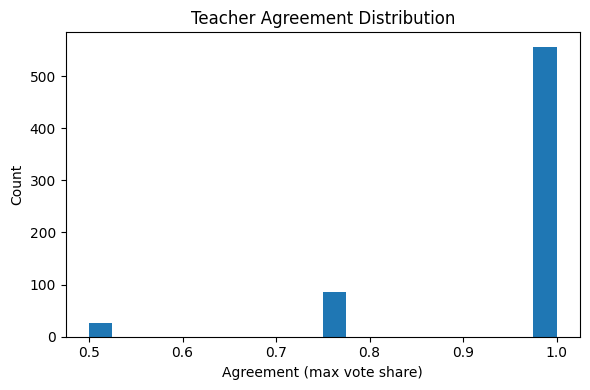

Saved table: /content/drive/MyDrive/NLP/outputs/tables/teacher_agreement_stats.csv


In [ ]:
df_raw["agreement"] = df_raw[["t_votes_pos","t_votes_neg"]].max(axis=1) / 4.0
plt.figure(figsize=(6,4))
plt.hist(df_raw["agreement"], bins=20)
plt.title("Teacher Agreement Distribution")
plt.xlabel("Agreement (max vote share)")
plt.ylabel("Count")
plt.tight_layout()
save_fig("teacher_agreement_hist.png")
plt.show()
save_table(df_raw["agreement"].describe().to_frame("agreement_stats"), "teacher_agreement_stats.csv")

Saved figure: /content/drive/MyDrive/NLP/outputs/plots/confidence_pos_neg_hist.png


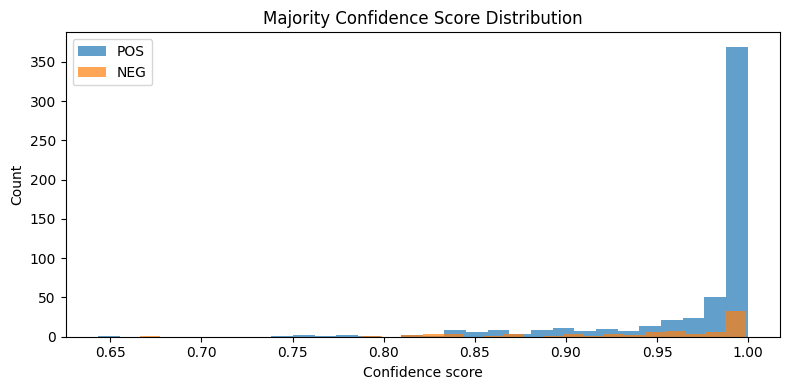

In [ ]:
# look at confidence distribution for POS vs NEG
maj = df_raw[df_raw["t_major_lab"].isin(["POS","NEG"])].copy()
plt.figure(figsize=(8,4))
plt.hist(maj[maj["t_major_lab"]=="POS"]["t_major_score"], bins=30, alpha=0.7, label="POS")
plt.hist(maj[maj["t_major_lab"]=="NEG"]["t_major_score"], bins=30, alpha=0.7, label="NEG")
plt.legend()
plt.title("Majority Confidence Score Distribution")
plt.xlabel("Confidence score")
plt.ylabel("Count")
plt.tight_layout()
save_fig("confidence_pos_neg_hist.png")
plt.show()

In [ ]:
# pseudo-labeling function:
# here I build my final labeled dataset based on teacher agreement + confidence

def make_labeled(df_in: pd.DataFrame, strict_majority=True, pos_th=0.75, neg_th=0.75):
    """
    Take teacher predictions and create a cleaner labeled subset.

    strict_majority=True:
      - keep only samples with strong agreement (>=3/4 votes) and high confidence

    strict_majority=False:
      - relax it to >=2 votes (more data, but also more noise)
      - still apply the confidence threshold
    """
    df = df_in.copy()

    if strict_majority:
        df = df[df["t_major_lab"].isin(["POS","NEG"])].copy()
        df["label"] = df["t_major_lab"]
        conf_ok = (
            ((df["label"]=="POS") & (df["t_major_score"] >= pos_th)) |
            ((df["label"]=="NEG") & (df["t_major_score"] >= neg_th))
        )
        df = df[conf_ok].copy()
    else:
        df["label"] = np.where(df["t_votes_pos"] >= 2, "POS",
                        np.where(df["t_votes_neg"] >= 2, "NEG", "NEU"))
        df = df[df["label"].isin(["POS","NEG"])].copy()
        conf_ok = (
            ((df["label"]=="POS") & (df["t_major_score"] >= pos_th)) |
            ((df["label"]=="NEG") & (df["t_major_score"] >= neg_th))
        )
        df = df[conf_ok].copy()

    return df

   threshold  size  POS  NEG
0       0.65   640  557   83
1       0.70   639  557   82
2       0.75   638  556   82
3       0.80   631  550   81
Saved table: /content/drive/MyDrive/NLP/outputs/tables/threshold_sensitivity.csv
Saved figure: /content/drive/MyDrive/NLP/outputs/plots/threshold_vs_size.png


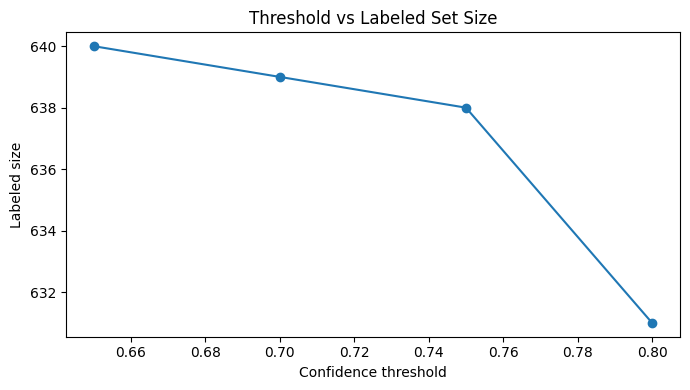

In [ ]:
# quick check: how much data do I get for different confidence thresholds?
def threshold_sensitivity(df_in, thresholds):
    rows = []
    for th in thresholds:
        tmp = make_labeled(df_in, strict_majority=True, pos_th=th, neg_th=th)
        dist = tmp["label"].value_counts().to_dict() if len(tmp) else {}
        rows.append({
            "threshold": th,
            "size": len(tmp),
            "POS": dist.get("POS", 0),
            "NEG": dist.get("NEG", 0)
        })
    return pd.DataFrame(rows)

sens = threshold_sensitivity(df_raw, [0.65, 0.70, 0.75, 0.80])
print(sens)
save_table(sens, "threshold_sensitivity.csv", index=False)

plt.figure(figsize=(7,4))
plt.plot(sens["threshold"], sens["size"], marker="o")
plt.title("Threshold vs Labeled Set Size")
plt.xlabel("Confidence threshold")
plt.ylabel("Labeled size")
plt.tight_layout()
save_fig("threshold_vs_size.png")
plt.show()

In [ ]:
# choose my final labeled set (strict setting first, fall back to looser one if too small)
df_lab = make_labeled(df_raw, strict_majority=True, pos_th=0.75, neg_th=0.75)
if len(df_lab) < 200:
    print("Strict labeled set is small -> switching to looser labeling rules")
    df_lab = make_labeled(df_raw, strict_majority=False, pos_th=0.70, neg_th=0.70)

checkpoint(df_lab, "final_labeled_set")
print(df_lab["label"].value_counts())
save_csv(df_lab, "pseudo_labels_final.csv")


[CHECKPOINT] final_labeled_set
shape: (638, 26)
   movie_id                     title      author  \
1       278  The Shawshank Redemption  John Chard   
3       278  The Shawshank Redemption   thommo_nz   

                                             content  \
1  Some birds aren't meant to be caged.\r\n\r\nTh...   
3  There is a reason why this movie is at the top...   

                 created_at  \
1  2016-07-10T00:16:50.561Z   
3  2018-05-01T05:51:13.756Z   

                                                text  is_en    t1_raw  \
1  Some birds aren't meant to be caged. The Shaws...   True  POSITIVE   
3  There is a reason why this movie is at the top...   True  POSITIVE   

   t1_score t1_lab  ...   t4_raw  t4_score t4_lab t_votes_pos  t_votes_neg  \
1  0.997052    POS  ...  LABEL_1  0.849160    POS           4            0   
3  0.998910    POS  ...  LABEL_1  0.999437    POS           4            0   

  t_major_lab t_major_score  vote_strength agreement  label  
1         P

Saved figure: /content/drive/MyDrive/NLP/outputs/plots/label_distribution.png


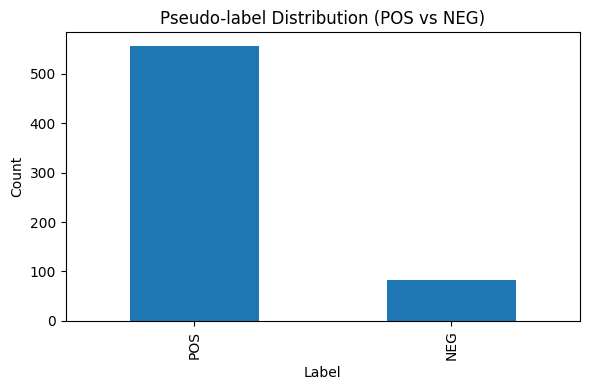

In [ ]:
# basic label distribution (just to see if it's balanced-ish)
plt.figure(figsize=(6,4))
df_lab["label"].value_counts().plot(kind="bar")
plt.title("Pseudo-label Distribution (POS vs NEG)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
save_fig("label_distribution.png")
plt.show()

Saved figure: /content/drive/MyDrive/NLP/outputs/plots/review_lengths_hist.png


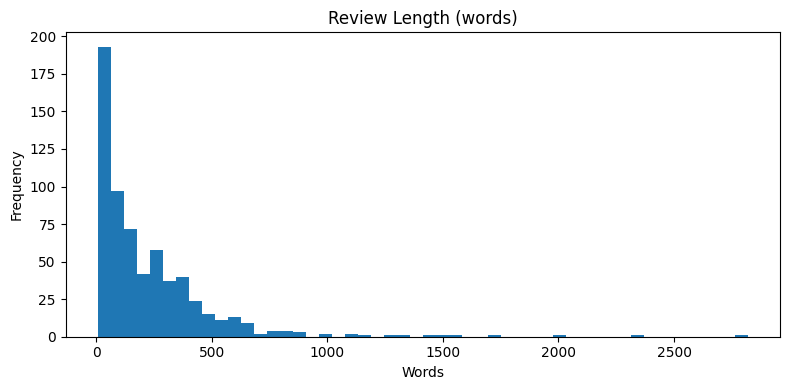

In [ ]:
# review length histogram (word-level)
lens = df_lab["text"].astype(str).map(lambda x: len(x.split()))
plt.figure(figsize=(8,4))
plt.hist(lens, bins=50)
plt.title("Review Length (words)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
save_fig("review_lengths_hist.png")
plt.show()

Saved figure: /content/drive/MyDrive/NLP/outputs/plots/wordcloud_pos_neg.png


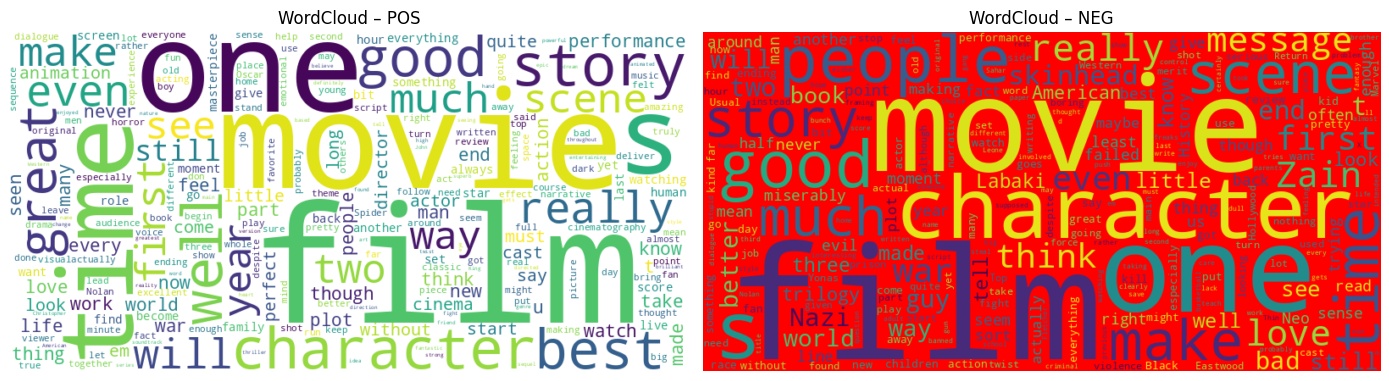

In [ ]:
# WordClouds for POS and NEG classes (just for a more visual intuition)
if set(["POS","NEG"]).issubset(set(df_lab["label"].unique())):
    pos_text = " ".join(df_lab[df_lab["label"]=="POS"]["text"].astype(str).tolist())
    neg_text = " ".join(df_lab[df_lab["label"]=="NEG"]["text"].astype(str).tolist())

    wc_pos = WordCloud(width=800, height=400, background_color="white",
                       stopwords=set(STOPWORDS), max_words=250, collocations=False).generate(pos_text)
    wc_neg = WordCloud(width=800, height=400, background_color="red",
                       stopwords=set(STOPWORDS), max_words=250, collocations=False).generate(neg_text)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(wc_pos, interpolation="bilinear"); axes[0].set_title("WordCloud – POS"); axes[0].axis("off")
    axes[1].imshow(wc_neg, interpolation="bilinear"); axes[1].set_title("WordCloud – NEG"); axes[1].axis("off")
    plt.tight_layout()
    save_fig("wordcloud_pos_neg.png")
    plt.show()

In [ ]:
# train/val/test split on the pseudo-labeled data
train_df, test_df = train_test_split(df_lab, test_size=0.15, random_state=SEED, stratify=df_lab["label"])
train_df, val_df  = train_test_split(train_df, test_size=0.15, random_state=SEED, stratify=train_df["label"])

save_csv(train_df, "train_split.csv")
save_csv(val_df,  "val_split.csv")
save_csv(test_df, "test_split.csv")

# small helper to summarize label distributions per split
def dataset_stats(dfx: pd.DataFrame, label_col="label"):
    total = len(dfx)
    pos = int((dfx[label_col] == "POS").sum())
    neg = int((dfx[label_col] == "NEG").sum())
    return {
        "#Samples": total,
        "Positive (%)": round(100 * pos / total, 1) if total else 0.0,
        "Negative (%)": round(100 * neg / total, 1) if total else 0.0,
    }

stats_df = pd.DataFrame({
    "Train": dataset_stats(train_df),
    "Validation": dataset_stats(val_df),
    "Test": dataset_stats(test_df),
}).T

table1 = stats_df.copy()

print("\n" + "="*80)
print("TABLE 1 (Dataset Statistics) — I'll just copy this into my LaTeX report later")
print(table1)
print("="*80 + "\n")

save_table(table1, "dataset_stats_splits.csv", index=True)

Saved CSV: /content/drive/MyDrive/NLP/outputs/train_split.csv
Saved CSV: /content/drive/MyDrive/NLP/outputs/val_split.csv
Saved CSV: /content/drive/MyDrive/NLP/outputs/test_split.csv

TABLE 1 (Dataset Statistics) — I'll just copy this into my LaTeX report later
            #Samples  Positive (%)  Negative (%)
Train          460.0          87.2          12.8
Validation      82.0          86.6          13.4
Test            96.0          87.5          12.5

Saved table: /content/drive/MyDrive/NLP/outputs/tables/dataset_stats_splits.csv


In [ ]:
# Baseline models: TF-IDF + Logistic Regression / Linear SVM

X_train = train_df["text"].astype(str).tolist()
X_test  = test_df["text"].astype(str).tolist()
y_train = (train_df["label"] == "POS").astype(int).values
y_test  = (test_df["label"] == "POS").astype(int).values

tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=40000, min_df=2)
Xtr = tfidf.fit_transform(X_train)
Xte = tfidf.transform(X_test)

lr = LogisticRegression(max_iter=4000, class_weight="balanced")
lr.fit(Xtr, y_train)
pred_lr = lr.predict(Xte)

svm = LinearSVC()
svm.fit(Xtr, y_train)
pred_svm = svm.predict(Xte)

baseline_df = pd.DataFrame([
    {
        "model":"TFIDF+LogReg",
        "ACC": accuracy_score(y_test, pred_lr),
        "BACC": balanced_accuracy_score(y_test, pred_lr),
        "MacroF1": f1_score(y_test, pred_lr, average="macro")
    },
    {
        "model":"TFIDF+LinearSVM",
        "ACC": accuracy_score(y_test, pred_svm),
        "BACC": balanced_accuracy_score(y_test, pred_svm),
        "MacroF1": f1_score(y_test, pred_svm, average="macro")
    },
])

print(baseline_df)
save_table(baseline_df, "baseline_results.csv", index=False)

             model       ACC      BACC   MacroF1
0     TFIDF+LogReg  0.895833  0.583333  0.614767
1  TFIDF+LinearSVM  0.875000  0.500000  0.466667
Saved table: /content/drive/MyDrive/NLP/outputs/tables/baseline_results.csv


In [ ]:
# Student model: DistilBERT fine-tuning on pseudo-labeled data

student_model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(student_model_name, use_fast=True)

def tok_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=256)

label2id = {"NEG":0, "POS":1}
id2label = {0:"NEG", 1:"POS"}

# Hugging Face datasets setup
train_ds = Dataset.from_pandas(
    train_df[["text","label"]].assign(labels=train_df["label"].map(label2id)).drop(columns=["label"]),
    preserve_index=False
)
val_ds = Dataset.from_pandas(
    val_df[["text","label"]].assign(labels=val_df["label"].map(label2id)).drop(columns=["label"]),
    preserve_index=False
)
test_ds = Dataset.from_pandas(
    test_df[["text","label"]].assign(labels=test_df["label"].map(label2id)).drop(columns=["label"]),
    preserve_index=False
)

ds = DatasetDict({"train": train_ds, "validation": val_ds, "test": test_ds}).map(tok_fn, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
    student_model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

def compute_metrics(eval_pred):
    logits, y_true = eval_pred
    y_pred = np.argmax(logits, axis=-1)
    return {
        "acc": accuracy_score(y_true, y_pred),
        "bacc": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/460 [00:00<?, ? examples/s]

Map:   0%|          | 0/82 [00:00<?, ? examples/s]

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# compute class weights based on the train set to handle potential imbalance
train_labels = np.array(ds["train"]["labels"])
neg_count = int((train_labels == 0).sum())
pos_count = int((train_labels == 1).sum())
total = int(len(train_labels))

w_neg = total / (2 * max(1, neg_count))
w_pos = total / (2 * max(1, pos_count))
class_weights = torch.tensor([w_neg, w_pos], dtype=torch.float)

cw_df = pd.DataFrame({"class":["NEG","POS"], "count":[neg_count,pos_count], "weight":[w_neg,w_pos]})
save_table(cw_df, "class_weights_for_loss.csv", index=False)

Saved table: /content/drive/MyDrive/NLP/outputs/tables/class_weights_for_loss.csv


In [ ]:
# NOTE:
# I'm not doing any aggressive hyperparameter search here.
# The main goal is to see how pseudo-label quality + dataset size affect the student model,
# not to squeeze out the absolute best score.

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, 2), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

args = TrainingArguments(
    output_dir=str(OUT_DIR / "student_distilbert"),
    per_device_train_batch_size=16,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.10,
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

trainer.train()

# save the fine-tuned student model into Drive
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))
print("Saved student model ->", MODEL_DIR)

Step,Training Loss
50,0.643600


Saved student model -> /content/drive/MyDrive/NLP/outputs/model


In [ ]:
# Final evaluation on the test set
pred = trainer.predict(ds["test"])
logits = pred.predictions
y_true = pred.label_ids
y_pred = np.argmax(logits, axis=-1)

acc = accuracy_score(y_true, y_pred)
bacc = balanced_accuracy_score(y_true, y_pred)
mf1 = f1_score(y_true, y_pred, average="macro")
print("Student DistilBERT -> ACC:", acc, "BACC:", bacc, "MacroF1:", mf1)

Student DistilBERT -> ACC: 0.8958333333333334 BACC: 0.6904761904761905 MacroF1: 0.7209302325581395


Saved figure: /content/drive/MyDrive/NLP/outputs/plots/confusion_matrix_studentt.png


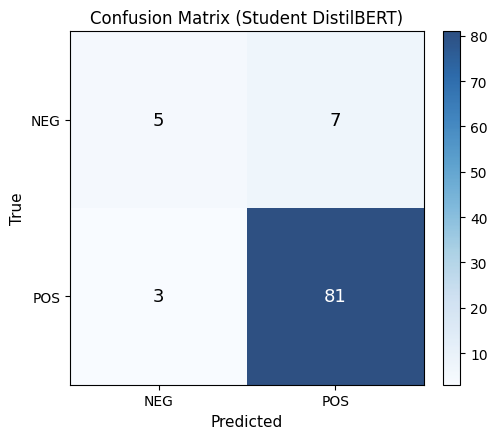


Confusion Matrix (Table Form):
          Pred_NEG  Pred_POS
True_NEG         5         7
True_POS         3        81
Saved table: /content/drive/MyDrive/NLP/outputs/tables/confusion_matrix_student_table.csv
              precision    recall  f1-score    support
NEG            0.625000  0.416667  0.500000  12.000000
POS            0.920455  0.964286  0.941860  84.000000
accuracy       0.895833  0.895833  0.895833   0.895833
macro avg      0.772727  0.690476  0.720930  96.000000
weighted avg   0.883523  0.895833  0.886628  96.000000
Saved table: /content/drive/MyDrive/NLP/outputs/tables/student_classwise_report.csv


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Confusion Matrix (Student DistilBERT) - improved but minimal changes
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5.5, 4.5))

# lighter look + nicer rendering
plt.imshow(cm, interpolation="nearest", cmap="Blues", alpha=0.85)

plt.title("Confusion Matrix (Student DistilBERT)", fontsize=12)
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("True", fontsize=11)

# show class names on axes
tick_labels = ["NEG", "POS"]
plt.xticks([0, 1], tick_labels, fontsize=10)
plt.yticks([0, 1], tick_labels, fontsize=10)

# write numbers on cells
thresh = cm.max() * 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            fontsize=13,
            color="white" if cm[i, j] > thresh else "black"
        )

plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
save_fig("confusion_matrix_studentt.png", dpi=300)  #
plt.show()

# Text form
cm_df = pd.DataFrame(
    cm,
    index=["True_NEG", "True_POS"],
    columns=["Pred_NEG", "Pred_POS"]
)
print("\nConfusion Matrix (Table Form):")
print(cm_df)
save_table(cm_df, "confusion_matrix_student_table.csv", index=True)

# Classification report stays the same (just keep it)
cls_report = classification_report(y_true, y_pred, target_names=["NEG","POS"], output_dict=True)
classwise_df = pd.DataFrame(cls_report).transpose()
print(classwise_df)
save_table(classwise_df, "student_classwise_report.csv", index=True)

In [ ]:
print("\nDONE.")
print("OUT_DIR:", OUT_DIR)
print("TABLE_DIR:", TABLE_DIR)
print("PLOT_DIR:", PLOT_DIR)


DONE.
OUT_DIR: /content/drive/MyDrive/NLP/outputs
TABLE_DIR: /content/drive/MyDrive/NLP/outputs/tables
PLOT_DIR: /content/drive/MyDrive/NLP/outputs/plots
